# KSB — Per-input kinematics and gap curves

Plots position, velocity, acceleration, jerk, and g_i(t) for each input.
The gap window replicates exactly the `[t_window_start, t_window_end]` logic
used inside `KSBSimulation.run()` / `compute_pairs()`.

In [28]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from ksb.simulation.ksb_simulation import KSBSimulation
from ksb.simulation.result import SimulationResult
from ksb.planning.solvers.scurve import SCurveSolver
from ksb.planning.solvers.quintic import QuinticSolver
from ksb.motion.trajectories import (
    CompositeTrajectory,
    ConstantJerkTrajectory,
    LinearTrajectory,
    PolynomialTrajectory,
    P, V, A,
)

import yaml
from pathlib import Path
with open(Path('..') / 'configs' / 'default.yaml') as f:
    cfg = yaml.safe_load(f)

cfg

{'solver': 'scurve',
 'jmax': 100.0,
 'Vmax': 3.0,
 'Amax': 8.5,
 'L_upstream': 2.0,
 'L_buffer': 2.5,
 'L_downstream': 1.0,
 'input_length': 0.32,
 'N': 5,
 'slot_length': 0.6,
 'input_gap_mean': 0.6,
 'input_gap_std': 0.05,
 'arrival_rate_ppm': 120,
 'slot_rate_ppm': 132,
 'batch': 100,
 'start_margin': 0.65,
 'end_margin': 0.0}

In [29]:
# ── Jerk helpers ──────────────────────────────────────────────────────────────
#
# TrajectoryProfile has no jerk() method on its base class.  We dispatch on
# concrete segment type.  eval_jerk() is recursive so that nested
# CompositeTrajectory segments (e.g. an S-curve composed of ConstantJerkTrajectory
# phases) are handled transparently.
# Returns None if any segment type is unrecognised; the caller leaves the
# jerk subplot blank.

def _jerk_segment(seg, t_arr: np.ndarray):
    """Jerk for a *primitive* (non-composite) segment at local times t_arr."""
    if isinstance(seg, ConstantJerkTrajectory):
        return np.full(len(t_arr), seg.jerk)
    if isinstance(seg, LinearTrajectory):
        return np.zeros(len(t_arr))
    if isinstance(seg, PolynomialTrajectory):
        return seg.poly.deriv(3)(t_arr)
    return None


def eval_jerk(traj, t_arr: np.ndarray):
    """Evaluate jerk for any TrajectoryProfile at times t_arr.

    For CompositeTrajectory, routes each sample to the correct segment and
    recurses, so nested composites are handled correctly.

    Returns ndarray shape (len(t_arr),), or None if an unknown segment type
    is encountered.
    """
    if not isinstance(traj, CompositeTrajectory):
        return _jerk_segment(traj, t_arr)

    cum_durs = np.cumsum([0.0] + [seg.T for seg in traj.segments])
    t_c = np.clip(t_arr, 0.0, traj.T)
    seg_indices = np.clip(
        np.searchsorted(cum_durs, t_c, side='right') - 1,
        0, len(traj.segments) - 1,
    )

    jerk_out = np.empty(len(t_arr))
    for seg_idx in np.unique(seg_indices):
        mask = seg_indices == seg_idx
        t_local = t_c[mask] - cum_durs[seg_idx]
        j = eval_jerk(traj.segments[seg_idx], t_local)
        if j is None:
            return None
        jerk_out[mask] = j
    return jerk_out

In [30]:
def plot_inputs(result: SimulationResult, N: int, n_samples: int = 500, i_start=0):
    """Plot kinematics and gap curves for the first N inputs.

    Parameters
    ----------
    result    : SimulationResult from KSBSimulation.run()
    N         : number of input rows to plot
    n_samples : evaluation points per trajectory domain (default 500)

    Figure layout: N rows × 5 columns
      col 0 — position (m)         ┐
      col 1 — velocity (m/s)       │  buffer trajectory for input i
      col 2 — acceleration (m/s²)  │
      col 3 — jerk (m/s³)          ┘  [blank if unsupported by segment type]
      col 4 — g_i(t): gap between input i and input i+1 (m)
               evaluated over exactly [t_window_start, t_window_end] as
               computed by KSBSimulation / compute_pairs
    """
    B = len(result.buffer_trajectories)
    assert N <= B, f"N={N} exceeds number of trajectories ({B})"

    COL_LABELS = [
        'Position (m)', 'Velocity (m/s)', 'Acceleration (m/s²)',
        'Jerk (m/s³)', r'Gap $g_i(t)$ (m)',
    ]

    fig, axes = plt.subplots(
        N, 5,
        figsize=(20, 3.2 * N),
        squeeze=False,
        constrained_layout=True,
    )
    fig.suptitle('KSB — per-input kinematics and gap curves', fontsize=14)

    for col, label in enumerate(COL_LABELS):
        axes[0, col].set_title(label, fontsize=11)

    for i in range(N):
        sb_traj = result.buffer_trajectories[i + i_start]

        # ── Kinematics (buffer segment only) ────────────────────────
        t = np.linspace(0.0, sb_traj.T, n_samples)
        states = sb_traj.eval(t)   # shape (3, n_samples)

        axes[i, 0].annotate(
            f'Input {i + i_start + 1}',
            xy=(-0.32, 0.5), xycoords='axes fraction',
            ha='center', va='center', fontsize=11, fontweight='bold', rotation=90,
        )

        # col 0 — position
        axes[i, 0].plot(t, states[P], color='C0')
        axes[i, 0].set_xlabel('t (s)')
        axes[i, 0].set_ylabel('p (m)')

        # col 1 — velocity
        axes[i, 1].plot(t, states[V], color='C1')
        axes[i, 1].set_xlabel('t (s)')
        axes[i, 1].set_ylabel('v (m/s)')
        axes[i, 1].set_ylim(0, cfg['Vmax'])

        # col 2 — acceleration
        axes[i, 2].plot(t, states[A], color='C2')
        axes[i, 2].set_xlabel('t (s)')
        axes[i, 2].set_ylabel('a (m/s²)')
        axes[i, 2].set_ylim(-cfg['Amax'],cfg['Amax']) 

        # col 3 — jerk (dispatch per segment type; blank if unsupported)
        jerk = eval_jerk(sb_traj, t)
        if jerk is not None:
            axes[i, 3].plot(t, jerk, color='C3')
            axes[i, 3].set_xlabel('t (s)')
            axes[i, 3].set_ylabel('j (m/s³)')
        else:
            axes[i, 3].axis('off')
            axes[i, 3].text(
                0.5, 0.5,
                'Jerk not available\n(segment type has no\nanalytical jerk method)',
                ha='center', va='center',
                transform=axes[i, 3].transAxes,
                fontsize=9, color='gray',
            )
        
        axes[i, 3].set_ylim(-cfg['jmax'], cfg['jmax'])

        # ── Gap g_i(t) ────────────────────────────────────────────────────────
        # Replicates compute_pairs() window logic exactly:
        #   t_window_start[i] = Lu_trajectories[i+1].T   (follower reaches L_upstream)
        #   t_window_end[i]   = t_window_start[i] + time_horizons[i]
        # Both are in the follower's (input i+1's) local time since t_spawn[i+1].
        # Stored in pair_records[i].t_start / t_end.
        #
        # gap(t_follow) = composite_traj_i.eval(t_follow + delta_t)[P]
        #               - composite_traj_{i+1}.eval(t_follow)[P]
        # where delta_t = t_spawn[i+1] - t_spawn[i] = pair_records[i].delta_t
        #
        # The x-axis is shifted so that t=0 corresponds to input i entering
        # the buffer: t_display = t_follow + t_spawn[i+1] - t_control_start[i]

        ax_gap = axes[i, 4]
        ax_gap.set_ylim(0, 2.0)

        if i >= B - 1:
            ax_gap.axis('off')
            ax_gap.text(0.5, 0.5, 'No follower\n(last input)',
                        ha='center', va='center',
                        transform=ax_gap.transAxes, fontsize=9, color='gray')
        else:
            pr = result.pair_records[i]

            # Follower local time window — identical to what compute_pairs received
            t_follow = np.linspace(pr.t_start, pr.t_end, n_samples)
            t_lead   = t_follow + pr.delta_t

            comp_lead   = result.composite_trajectories[i]
            comp_follow = result.composite_trajectories[i + 1]

            p_lead   = comp_lead.eval(t_lead)[P]
            p_follow = comp_follow.eval(t_follow)[P]
            gap      = p_lead - p_follow

            # Shift x-axis: t=0 ↔ input i enters buffer (t_control_start[i])
            t_offset  = result.t_spawn[i + 1] - result.t_control_start[i]
            t_display = t_follow + t_offset

            ax_gap.plot(t_display, gap, color='C4', label=r'$g_i(t)$')
            ax_gap.set_xlabel('t (s, rel. to input i buffer entry)')
            ax_gap.set_ylabel('gap (m)')

            # g_min dashed reference
            g_min = pr.g_min_threshold
            if g_min > 0.0:
                ax_gap.axhline(
                    g_min, color='red', linestyle='--', linewidth=1.2,
                    label=fr'$g_{{\min}}$ = {g_min:.3f} m',
                )
            ax_gap.legend(fontsize=8)

    plt.show()
    return fig

[20 30 36 46 56 65 78 90]


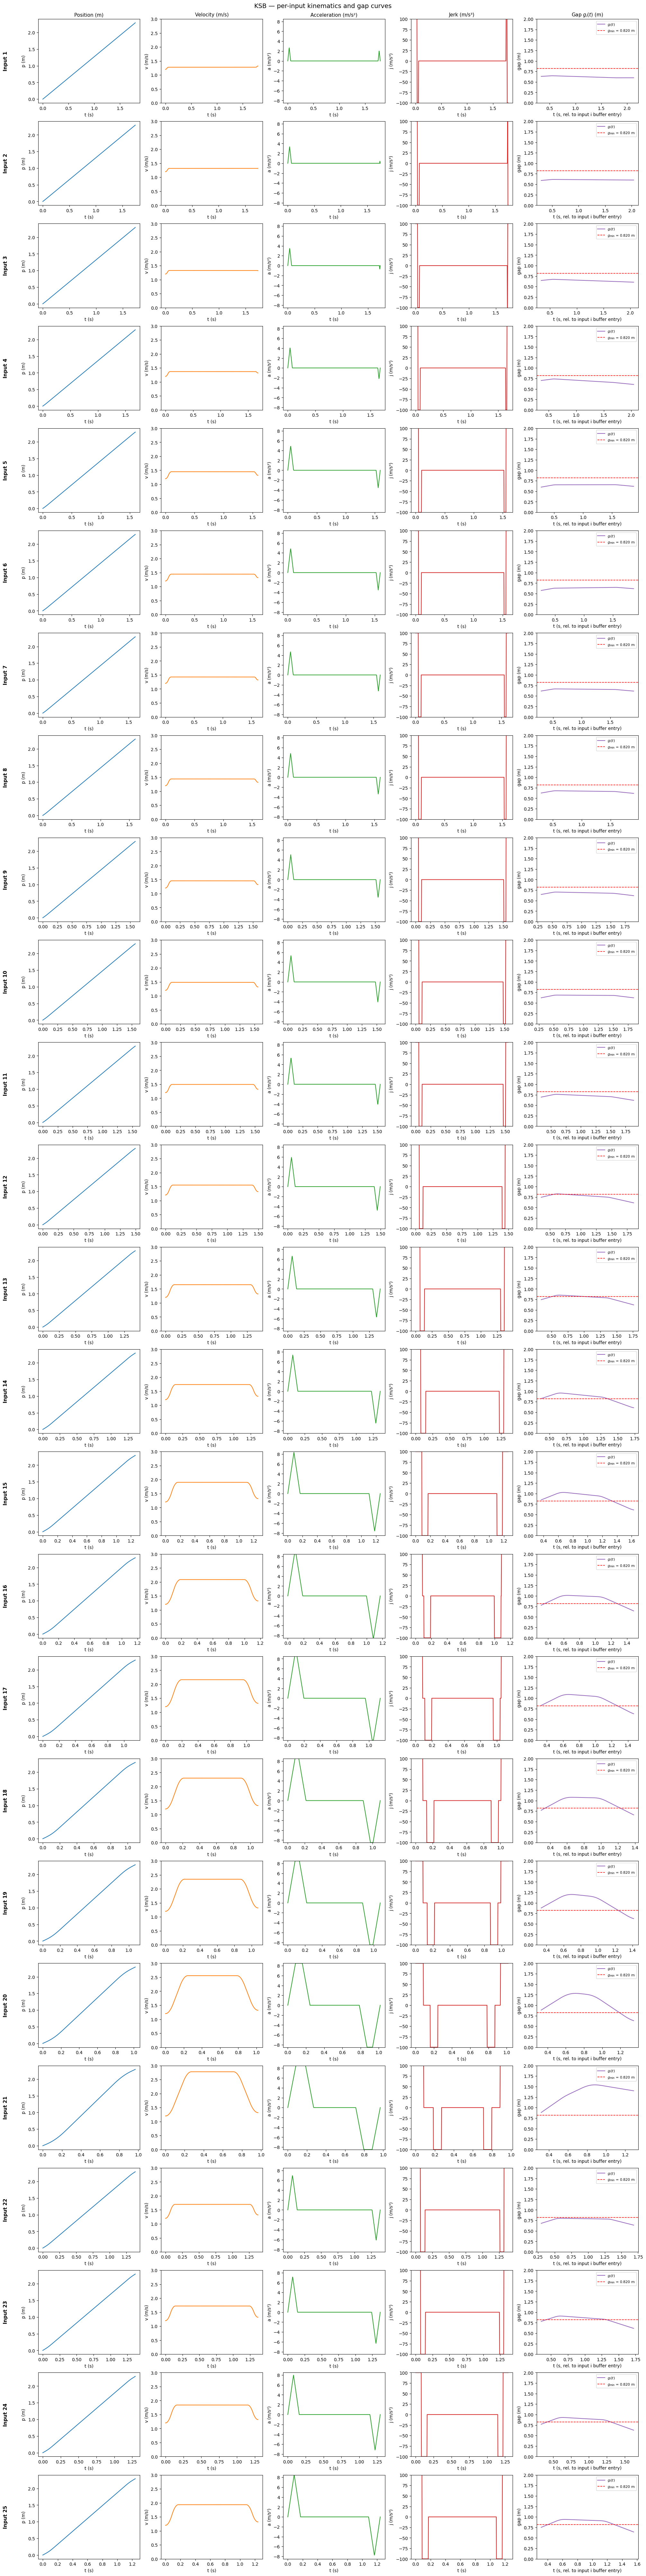

In [31]:
# ── Run simulation and display ────────────────────────────────────────────────
solver = SCurveSolver()
sim: KSBSimulation = KSBSimulation(cfg=cfg, solver=solver)
result: SimulationResult = sim.run(seed=42)
print(result.skip_indices)

fig = plot_inputs(result, N=25, i_start=0)

